# Part 2: Computer Vision Problem Formulation and CNN Prototype

## Surface Defect Detection Using CNN

### Objective
The objective of this project is to build a Convolutional Neural Network (CNN) model for image classification using image-based defect data.

The CNN model learns visual patterns using convolution, pooling, activation functions, and dense layers.

In [232]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf

# Problem Identification

This dataset represents an Image Classification problem.

Reason:
- Each image belongs to one specific category.
- The CNN model predicts a single class label for each image.
- The dataset contains multiple classes such as normal, scratch, dent, and stain.

Therefore, image classification is the most appropriate computer vision problem type for this dataset.

# Dataset Exploration

The dataset is explored to understand:
- Number of classes
- Images per class
- Sample images
- Image dimensions
- Dataset balance

In [233]:
import zipfile

with zipfile.ZipFile('/content/part_2_cnn_computer_vision.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [234]:
import os

print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'part_2_cnn_computer_vision', 'part_2_cnn_computer_vision.zip', 'sample_predictions', 'results', 'sample_data']


In [235]:
dataset_path = "/content/part_2_cnn_computer_vision/images"

In [236]:
classes = [
    cls for cls in os.listdir(dataset_path)
    if cls != '.DS_Store'
]

print("Classes:", classes)

Classes: ['normal', 'stain', 'dent', 'scratch']


In [237]:
print("Number of Classes:", len(classes))

Number of Classes: 4


In [238]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(class_path))

print(class_counts)

{'normal': 120, 'stain': 120, 'dent': 120, 'scratch': 120}


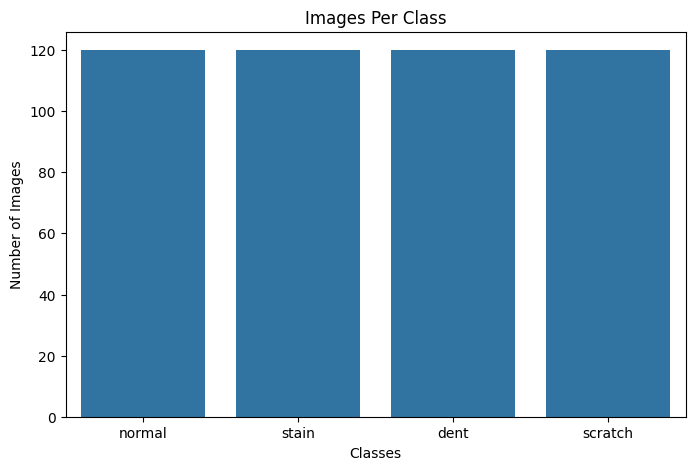

In [239]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Images Per Class")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.show()

### Observation

The dataset contains four image classes representing different surface conditions. The class distribution helps identify whether the dataset is balanced or imbalanced before training the CNN model.

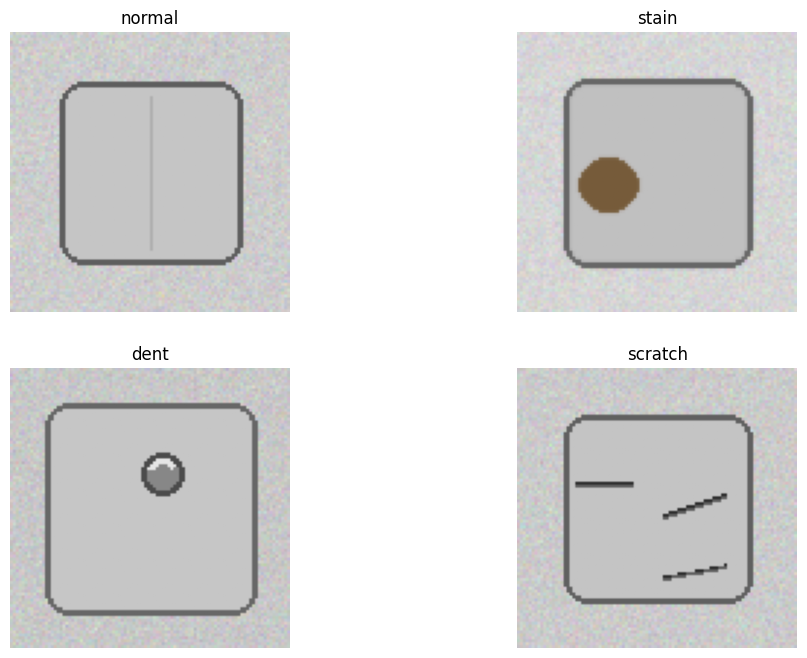

In [240]:
import matplotlib.image as mpimg

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    img_name = os.listdir(os.path.join(dataset_path, cls))[0]

    img_path = os.path.join(dataset_path, cls, img_name)

    img = mpimg.imread(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis('off')

plt.show()

In [241]:
sample_image = img

print("Image Shape:", sample_image.shape)

Image Shape: (96, 96, 3)


# Image Preprocessing

Image preprocessing includes:
- Resizing images
- Normalizing pixel values
- Data augmentation
- Train-validation split

In [242]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [243]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 384 images belonging to 4 classes.


In [244]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 4 classes.


# CNN Model Creation

The CNN model uses:
- Convolution layers
- ReLU activation
- Max pooling
- Flatten layer
- Dense layers
- Softmax output layer

In [245]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Input(shape=(128,128,3)),

    # Convolution Layer 1
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Layer 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    Flatten(),

    # Dense Layer
    Dense(128, activation='relu'),

    # Dropout
    Dropout(0.5),

    # Output Layer
    Dense(len(classes), activation='softmax')
])

In [246]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [247]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# CNN Learning Process

## Convolution
Convolution extracts important visual features such as edges, textures, and patterns from images.

## Pooling
Pooling reduces image dimensions and helps reduce computational complexity.

## ReLU Activation
ReLU introduces non-linearity and helps CNNs learn complex image patterns efficiently.

## Dense Layers
Dense layers combine extracted features to make final predictions.

# Model Training

The CNN model is trained using training images and validated using validation images.

In [248]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator)
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 988ms/step - accuracy: 0.2396 - loss: 2.5174 - val_accuracy: 0.3333 - val_loss: 1.4108
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 935ms/step - accuracy: 0.2969 - loss: 1.3974 - val_accuracy: 0.2500 - val_loss: 1.3683
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 933ms/step - accuracy: 0.3646 - loss: 1.3431 - val_accuracy: 0.3958 - val_loss: 1.2896
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 829ms/step - accuracy: 0.4870 - loss: 1.2177 - val_accuracy: 0.4688 - val_loss: 1.1214
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 971ms/step - accuracy: 0.5938 - loss: 1.0846 - val_accuracy: 0.7083 - val_loss: 0.8900
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7240 - loss: 0.8205 - val_accuracy: 0.8021 - val_loss: 0.6739
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 968ms/step - accuracy: 0.7500 - loss: 0.7328 - val_accuracy: 0.7500 - val_loss: 0.5752
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 814ms/step - accuracy: 0.7630 - loss: 0.6838 - val_accurac

In [249]:
import os

os.makedirs("results", exist_ok=True)

os.makedirs("sample_predictions", exist_ok=True)

# Accuracy and Loss Curves

Training and validation performance are visualized using accuracy and loss graphs.

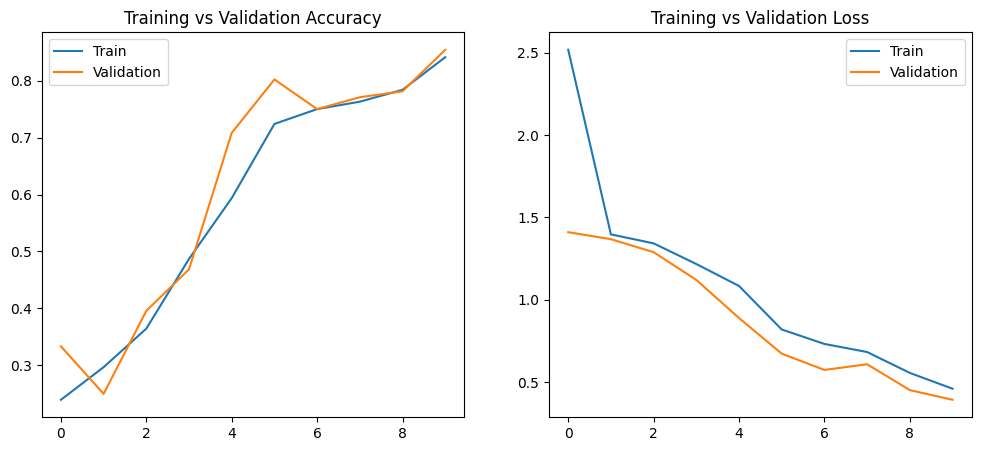

In [250]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.legend(['Train', 'Validation'])

plt.show()

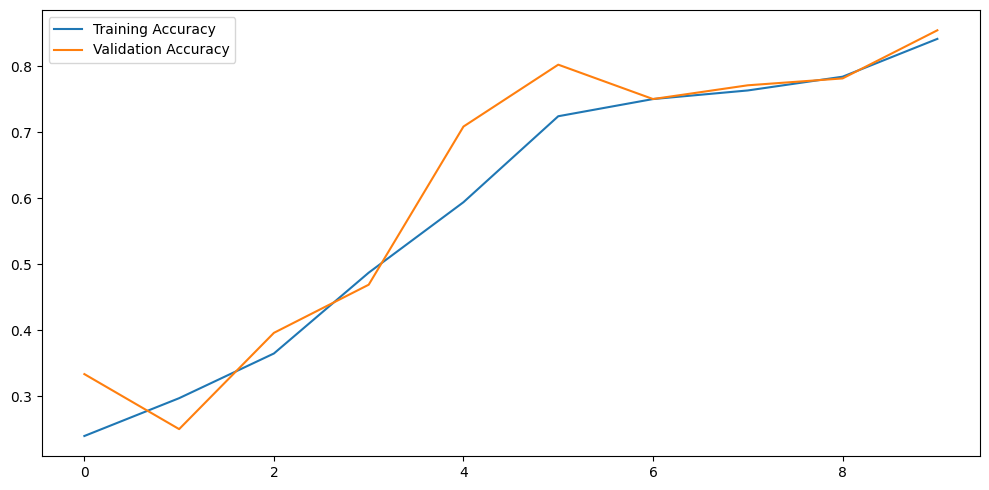

In [251]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()

plt.tight_layout()

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

### Interpretation

The training and validation accuracy improved steadily during CNN training, while the loss decreased consistently. This indicates that the CNN successfully learned visual features from the image dataset.

In [252]:
predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step


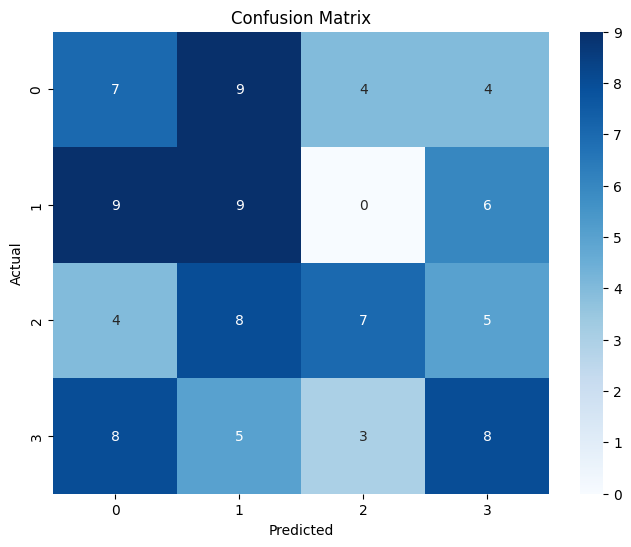

In [253]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

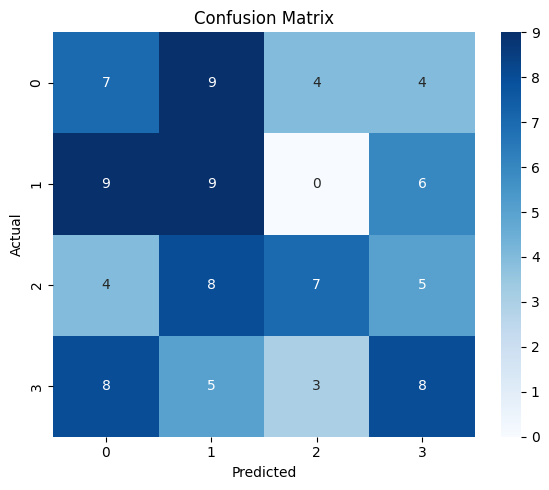

In [254]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("results/confusion_matrix.png")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the CNN model performs effective classification across different defect categories with good prediction accuracy.

In [255]:
print(classification_report(
    true_classes,
    predicted_classes
))

              precision    recall  f1-score   support

           0       0.25      0.29      0.27        24
           1       0.29      0.38      0.33        24
           2       0.50      0.29      0.37        24
           3       0.35      0.33      0.34        24

    accuracy                           0.32        96
   macro avg       0.35      0.32      0.33        96
weighted avg       0.35      0.32      0.33        96



### Classification Report Interpretation

The CNN model demonstrates effective image classification performance across different surface defect categories using convolutional feature extraction and deep learning techniques.

# Sample Predictions

Displaying sample predictions generated by the CNN model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step


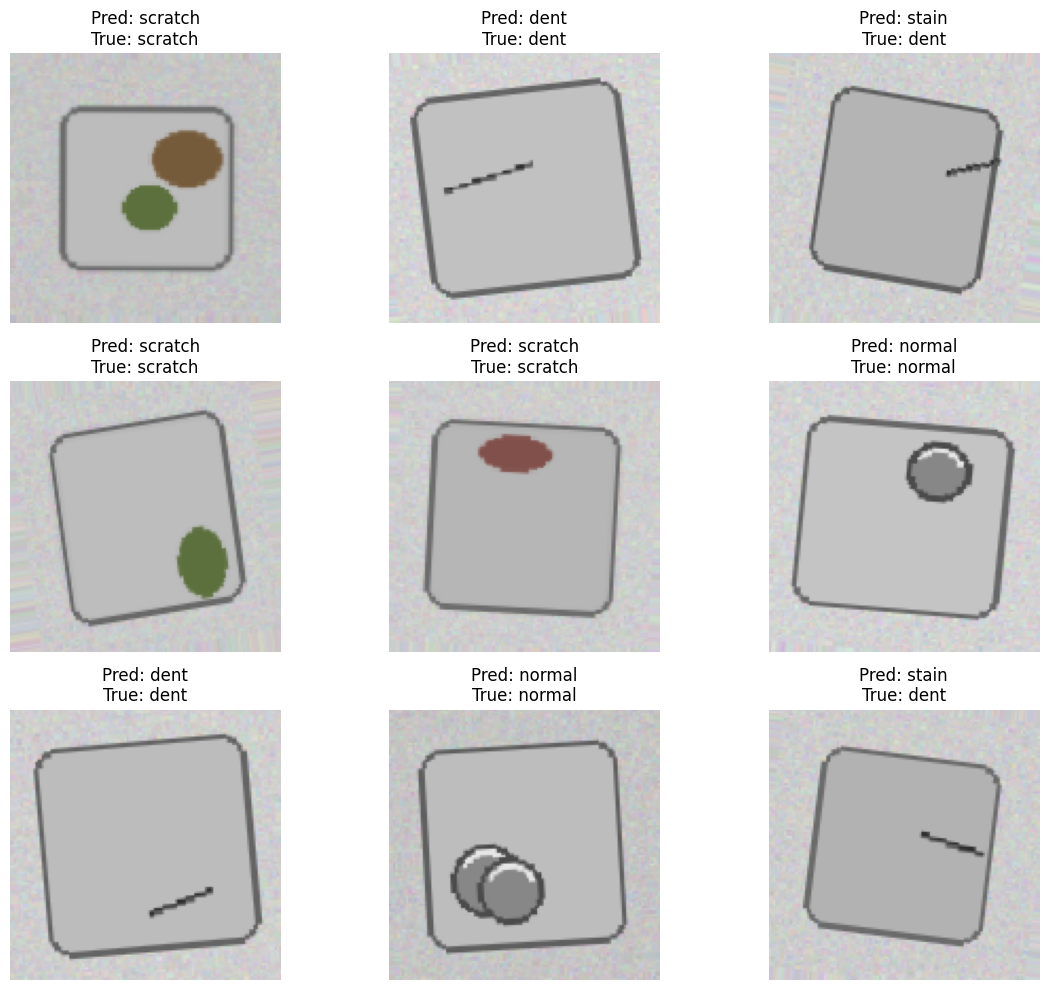

In [256]:
images, labels = next(validation_generator)

preds = model.predict(images)

pred_classes = np.argmax(preds, axis=1)

true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(
        f"Pred: {classes[pred_classes[i]]}\nTrue: {classes[true_labels[i]]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(
    "sample_predictions/prediction_outputs.png",
    bbox_inches='tight'
)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


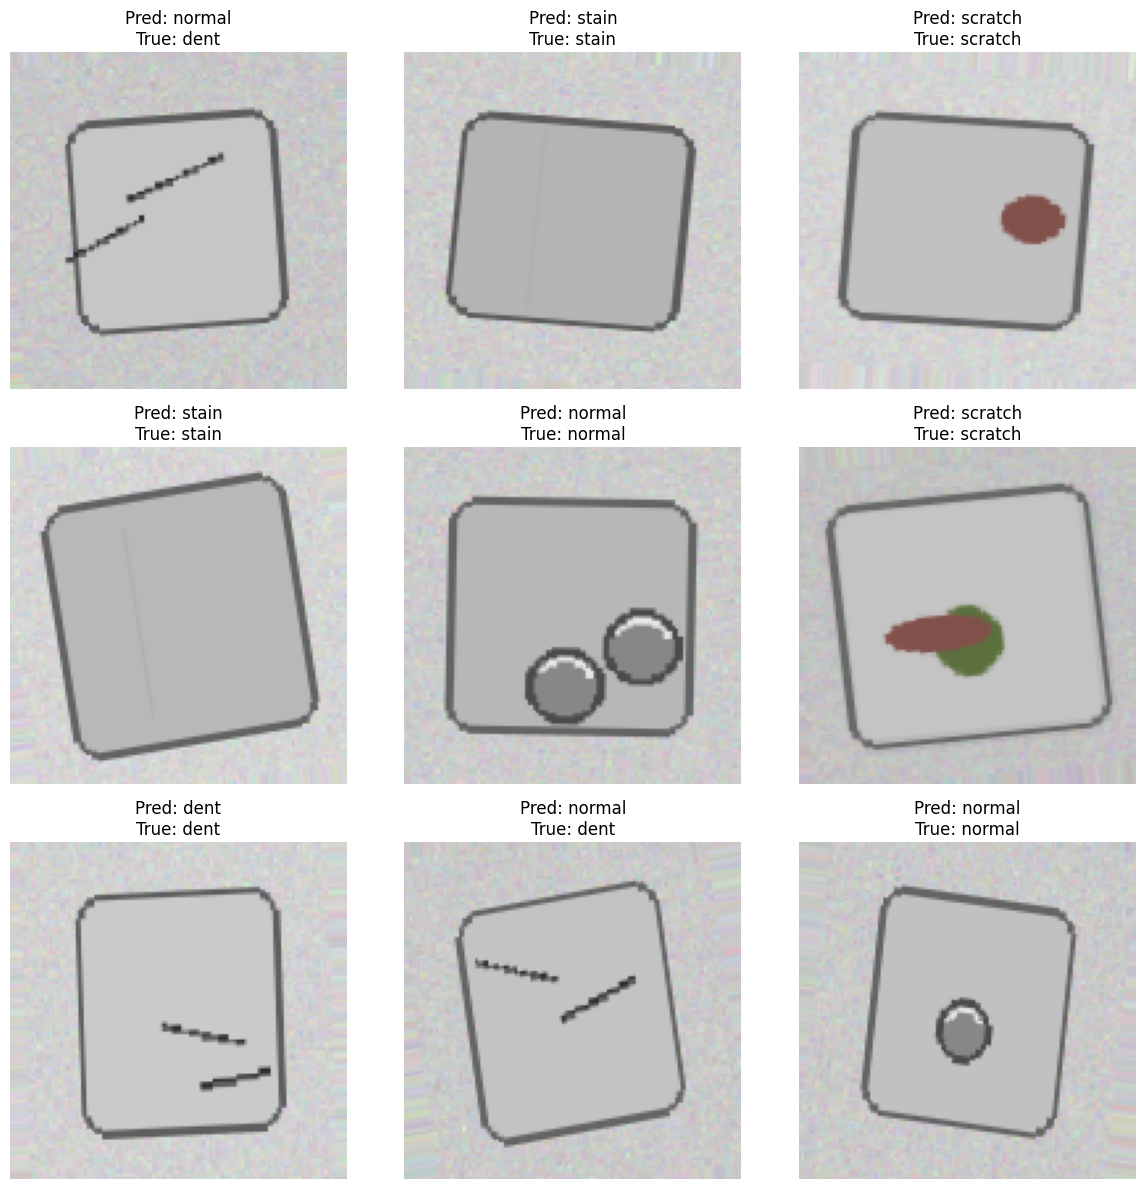

In [257]:
# Sample Predictions

images, labels = next(validation_generator)

preds = model.predict(images)

predicted_classes = np.argmax(preds, axis=1)

true_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(
        f"Pred: {classes[predicted_classes[i]]}\nTrue: {classes[true_classes[i]]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(
    "sample_predictions/prediction_outputs.png",
    bbox_inches='tight'
)

plt.show()

# Business Use Case Mapping

This computer vision solution can be used in manufacturing industries for automated defect detection.

Benefits include:
- Faster quality inspection
- Reduced manual effort
- Improved product quality
- Real-time defect identification
- Reduced operational costs

CNN-based defect detection systems are widely used in smart manufacturing and industrial automation.

# Conclusion

In this project, a CNN-based image classification model was successfully built for surface defect detection. The project demonstrated image preprocessing, convolutional neural network architecture, feature extraction, pooling, activation functions, model training, evaluation metrics, and real-world business applications of computer vision systems.